In [ ]:
import zarr.storage
import ngff_zarr as nz

ZARR_PATH = "s3://osco-390179198112-ap-northeast-2-an/52794_1490_HIC_20260616_H460-NucR_DTX_DRC_20X.zarr/"

# Open as an FsspecStore object (not a plain string) so ngff_zarr's HCSWell.get_image()
# takes the StorePath branch instead of wrapping the S3 URI in pathlib.Path, which
# collapses "s3://" to "s3:/" and breaks well/image loading.
store = zarr.storage.FsspecStore.from_url(ZARR_PATH, read_only=True)
plate = nz.from_hcs_zarr(store)

In [ ]:
print(f"Plate: {plate.metadata.name}")
print(f"Rows: {len(plate.metadata.rows)}")
print(f"Columns: {len(plate.metadata.columns)}")
print(f"Wells: {len(plate.metadata.wells)}")

# Access a specific well
well = plate.get_well("B", "2")
if well:
    print(f"Well B/2 has {len(well.images)} field(s)")

    # Get the first field image
    field = well.get_image(0)
    if field:
        print(f"Field 0 has {len(field.images)} image(s)")
        print(f"Image shape: {field.images[0].data.shape}")

Plate: HIC_20260616_H460-NucR_DTX DRC_20X
Rows: 5
Columns: 7
Wells: 33
Well B/2 has 9 field(s)
Field 0 has 6 image(s)
Image shape: (147, 2, 1, 1040, 1408)
dask.array<getitem, shape=(1040, 1408), dtype=uint16, chunksize=(1040, 1408), chunktype=numpy.ndarray>


In [20]:
print(plate.get_well("B", "2").images[0])

WellImage(path='1', acquisition=0)


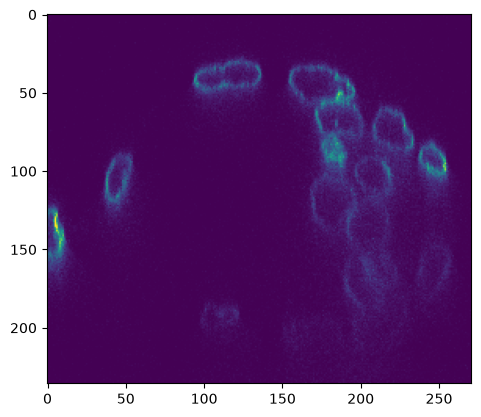

In [ ]:
img = lz.level(0).time(0).z(100).compute()

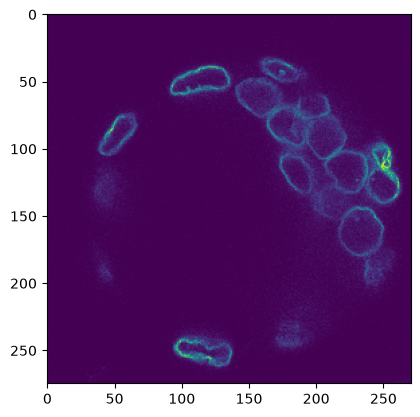

In [10]:


img = lz.ome_zarr.images[0].data[0, 100, :, :]
plt.imshow(img)

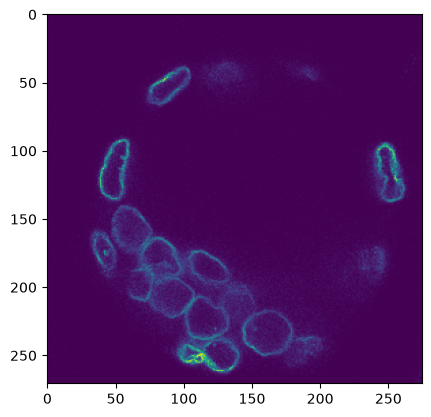

In [ ]:

img = lz.get_plane(0, 0, 100)
plt.imshow(img)

In [46]:
zarr_img.images

[OMEZarrImage(data=dask.array<from-zarr, shape=(2, 236, 275, 271), dtype=uint16, chunksize=(1, 1, 256, 256), chunktype=numpy.ndarray>, axes=['c', 'z', 'y', 'x'], scale={'c': 1.0, 'z': 0.5002025531914894, 'y': 0.3603981534640209, 'x': 0.3603981534640209}, axes_units={'z': 'micrometer', 'y': 'micrometer', 'x': 'micrometer'}, name='image'),
 OMEZarrImage(data=dask.array<from-zarr, shape=(2, 236, 137, 135), dtype=uint16, chunksize=(1, 1, 137, 135), chunktype=numpy.ndarray>, axes=['c', 'z', 'y', 'x'], scale={'c': 1.0, 'z': 0.5002025531914894, 'y': 0.7207963069280418, 'x': 0.7207963069280418}, axes_units={'z': 'micrometer', 'y': 'micrometer', 'x': 'micrometer'}, name='image'),
 OMEZarrImage(data=dask.array<from-zarr, shape=(2, 236, 68, 67), dtype=uint16, chunksize=(1, 1, 68, 67), chunktype=numpy.ndarray>, axes=['c', 'z', 'y', 'x'], scale={'c': 1.0, 'z': 0.5002025531914894, 'y': 1.4415926138560835, 'x': 1.4415926138560835}, axes_units={'z': 'micrometer', 'y': 'micrometer', 'x': 'micrometer'},